# EDA — Capítulo 2: Diagnóstico y Análisis Exploratorio

**Tesis:** Detección de anomalías transaccionales en pagos digitales mediante Isolation Forest  
**OE2:** Caracterizar los patrones transaccionales asociados a la condición proxy de anomalía  
**Fuente:** Parquets congelados Fase 1 — `data/processed/`  
**Snapshot:** 2026-03-17

Todos los artefactos se generan automáticamente. Ningún número del Capítulo 2 se edita manualmente.

---
**Hallazgo estructural clave:** El 26% del universo tiene `status=''` (cadena vacía).  
Estos son pagos con métodos alternativos (cash, prepaid, check, ACH, user_package) que  
no pasan por un procesador de tarjeta → no reciben status de captura del gateway.  
Son transacciones legítimas dentro del universo de estudio.

In [1]:
import gc
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

from config.config import settings
from fraud_detector.data.loader import DataManager

settings.ensure_directories()
FIG = settings.figures_dir
TAB = settings.tables_dir
MET = settings.metrics_dir

# ── Estilo unificado thesis ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'font.size': 11,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})
C_NORMAL  = '#4C72B0'  # azul — proxy-
C_ANOMALY = '#DD8452'  # naranja — proxy+
C_NEUTRAL = '#55A868'  # verde — neutral
C_ALT     = '#8172B2'  # violeta — métodos alternativos

# ── Labels de status ────────────────────────────────────────────────────────
STATUS_LABELS = {
    'captured':            'Capturado',
    '':                    'Pago alternativo (sin estado)',
    'totally_refunded':    'Reembolso total',
    'refunded_to_credit':  'Reembolso a crédito',
    'partially_refunded':  'Reembolso parcial',
    'authorized':          'Autorizado',
}
PROXY_STRICT = {'totally_refunded', 'refunded_to_credit'}
PROXY_WIDE   = {'totally_refunded', 'refunded_to_credit', 'partially_refunded'}
ALT_METHODS  = {'cash', 'prepaid', 'check', 'accounts_receivable', 'user_package', 'ach'}

dm = DataManager(settings)
print('Setup OK')
print(f'  Figuras:  {FIG}')
print(f'  Tablas:   {TAB}')
print(f'  Métricas: {MET}')

2026-03-17 21:50:33 | INFO     | fraud_detector.utils.logger:setup_logger:83 - Logger initialized successfully


2026-03-17 21:50:33 | INFO     | fraud_detector.utils.logger:setup_logger:84 - Environment: development


2026-03-17 21:50:33 | INFO     | fraud_detector.utils.logger:setup_logger:85 - Log level: INFO


2026-03-17 21:50:33 | INFO     | fraud_detector:<module>:8 - Fraud Detector v0.1.0 initialized


Setup OK
  Figuras:  /Users/eidan/Documentation/Personal/Master/Perfil/ml-fraud-detector/output/figures
  Tablas:   /Users/eidan/Documentation/Personal/Master/Perfil/ml-fraud-detector/output/tables
  Métricas: /Users/eidan/Documentation/Personal/Master/Perfil/ml-fraud-detector/output/metrics


## 2.1 Resumen del Dataset
Sección: **Capítulo 2 — Fuente de datos y proceso de depuración**

Carga secuencial por split para mantener pico de memoria < 4 GB.

In [2]:
split_stats = {}

for name in ['train', 'val', 'test']:
    df = dm.load_split(name)
    df['amount'] = df['amount'].astype(float)
    is_proxy_strict = df['status'].isin(PROXY_STRICT)
    is_proxy_wide   = df['status'].isin(PROXY_WIDE)
    is_alt          = df['payment_method'].isin(ALT_METHODS)
    split_stats[name] = {
        'rows':             int(len(df)),
        'proxy_strict_n':   int(is_proxy_strict.sum()),
        'proxy_strict_rate':float(is_proxy_strict.mean()),
        'proxy_wide_n':     int(is_proxy_wide.sum()),
        'proxy_wide_rate':  float(is_proxy_wide.mean()),
        'alt_payment_n':    int(is_alt.sum()),
        'alt_payment_rate': float(is_alt.mean()),
        'amount_zero_n':    int((df['amount'] == 0).sum()),
        'amount_zero_pct':  float((df['amount'] == 0).mean() * 100),
        'date_min':         str(df['created_at'].min()),
        'date_max':         str(df['created_at'].max()),
    }
    print(f"{name:6s}: {len(df):>10,} | proxy_strict={is_proxy_strict.mean()*100:.2f}% "
          f"| alt_payment={is_alt.mean()*100:.1f}% "
          f"| {df['created_at'].min().date()} .. {df['created_at'].max().date()}")
    del df, is_proxy_strict, is_proxy_wide, is_alt
    gc.collect()

total_rows = sum(s['rows'] for s in split_stats.values())
total_ps   = sum(s['proxy_strict_n'] for s in split_stats.values())
total_pw   = sum(s['proxy_wide_n']   for s in split_stats.values())
total_alt  = sum(s['alt_payment_n']  for s in split_stats.values())
print(f"\nTotal: {total_rows:,}")
print(f"  proxy_strict: {total_ps:,} ({total_ps/total_rows*100:.2f}%)")
print(f"  proxy_wide:   {total_pw:,} ({total_pw/total_rows*100:.2f}%)")
print(f"  alt_payment:  {total_alt:,} ({total_alt/total_rows*100:.2f}%)")

2026-03-17 21:50:36 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


train :  3,137,085 | proxy_strict=6.45% | alt_payment=27.2% | 2025-01-01 .. 2025-06-30


2026-03-17 21:50:38 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded val: 1,130,118 rows


val   :  1,130,118 | proxy_strict=6.07% | alt_payment=28.4% | 2025-07-01 .. 2025-08-31


2026-03-17 21:50:40 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded test: 2,517,491 rows


test  :  2,517,491 | proxy_strict=6.30% | alt_payment=28.6% | 2025-09-01 .. 2025-12-31

Total: 6,784,694
  proxy_strict: 429,498 (6.33%)
  proxy_wide:   512,676 (7.56%)
  alt_payment:  1,893,554 (27.91%)


## 2.2 Distribución de Status
Sección: **Capítulo 2 — Variable criterio (proxy de anomalía)**

> **Nota metodológica:** El 26% del universo tiene `status=''` (cadena vacía). Estos corresponden
> a pagos con métodos alternativos (cash, prepaid, check, ACH, paquetes de usuario) que no pasan
> por un procesador de tarjeta bancaria y por tanto no reciben un status de captura del gateway.
> Son transacciones legítimas del ecosistema TechSport, incluidas en el universo de estudio.

In [3]:
# Agregar status secuencialmente sobre los 3 splits
status_agg   = {}   # {status: {'n': int, 'amt_sum': float, 'amt_count': int}}

for name in ['train', 'val', 'test']:
    df = dm.load_split(name)[['status', 'amount']]
    df['amount'] = df['amount'].astype(float)
    for s, grp in df.groupby('status', observed=True):
        if s not in status_agg:
            status_agg[s] = {'n': 0, 'amt_sum': 0.0, 'amt_count': 0}
        status_agg[s]['n']         += len(grp)
        status_agg[s]['amt_sum']   += float(grp['amount'].sum())
        status_agg[s]['amt_count'] += int((grp['amount'] > 0).sum())
    del df; gc.collect()

status_df = pd.DataFrame([
    {'status': s,
     'label':  STATUS_LABELS.get(s, s),
     'n':      v['n'],
     'pct':    v['n'] / total_rows * 100,
     'amount_mean': v['amt_sum'] / v['n'] if v['n'] > 0 else 0,
     'is_proxy_strict': s in PROXY_STRICT,
     'is_alt': s == '',
    }
    for s, v in status_agg.items()
]).sort_values('n', ascending=False).reset_index(drop=True)

print(status_df[['label','n','pct','amount_mean']].to_string(index=False, float_format='%.2f'))

2026-03-17 21:50:43 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


2026-03-17 21:50:45 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded val: 1,130,118 rows


2026-03-17 21:50:47 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded test: 2,517,491 rows


                        label       n   pct  amount_mean
                    Capturado 4502072 66.36       198.97
Pago alternativo (sin estado) 1769193 26.08      1778.49
              Reembolso total  326055  4.81       261.33
          Reembolso a crédito  103443  1.52      1236.39
            Reembolso parcial   83178  1.23        42.58
                   Autorizado     753  0.01       327.61


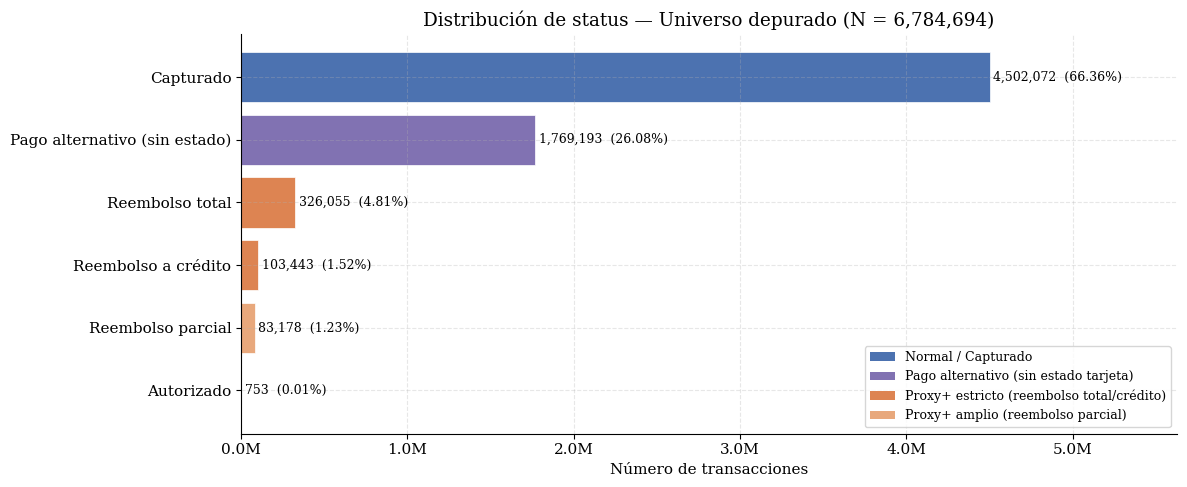

Figura y tabla guardadas.


In [4]:
# ── Figura: distribución de status ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

color_map = []
for _, row in status_df.iterrows():
    if row['is_proxy_strict']:  color_map.append(C_ANOMALY)
    elif row['status'] == 'partially_refunded': color_map.append('#E8A87C')
    elif row['is_alt']:         color_map.append(C_ALT)
    else:                       color_map.append(C_NORMAL)

bars = ax.barh(status_df['label'], status_df['n'], color=color_map, edgecolor='white', linewidth=0.5)
for bar, pct, n in zip(bars, status_df['pct'], status_df['n']):
    ax.text(bar.get_width() + total_rows * 0.003, bar.get_y() + bar.get_height() / 2,
            f'{n:,}  ({pct:.2f}%)', va='center', fontsize=9)

ax.set_xlabel('Número de transacciones')
ax.set_title(f'Distribución de status — Universo depurado (N = {total_rows:,})')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.invert_yaxis()
ax.set_xlim(0, max(status_df['n']) * 1.25)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_NORMAL,  label='Normal / Capturado'),
    Patch(facecolor=C_ALT,     label='Pago alternativo (sin estado tarjeta)'),
    Patch(facecolor=C_ANOMALY, label='Proxy+ estricto (reembolso total/crédito)'),
    Patch(facecolor='#E8A87C', label='Proxy+ amplio (reembolso parcial)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_status_distribution.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla LaTeX ──────────────────────────────────────────────────────────────
tex_df = status_df[['label','n','pct','amount_mean']].copy()
tex_df.columns = ['Status', 'N', '\\% Universo', 'Monto Prom. (USD)']
tex_df['N'] = tex_df['N'].apply(lambda x: f'{int(x):,}')
tex_df['\\% Universo'] = tex_df['\\% Universo'].apply(lambda x: f'{x:.2f}\\%')
tex_df['Monto Prom. (USD)'] = tex_df['Monto Prom. (USD)'].apply(lambda x: f'\\${x:,.2f}')
latex = tex_df.to_latex(index=False, escape=False,
    caption='Distribución de status en el universo depurado (N=6{,}784{,}694)',
    label='tab:status-distribution', column_format='lrrr')
(TAB / 'cap2_status_distribution.tex').write_text(latex)
print('Figura y tabla guardadas.')

## 2.3 Métodos de Pago: Tarjeta vs. Alternativos
Sección: **Capítulo 2 — Caracterización del ecosistema transaccional**

Los métodos alternativos (cash, prepaid, check, ACH) no interactúan con gateways bancarios  
y representan el segmento de `status=''`. Son fundamentales para entender la distribución de montos.

In [5]:
source_counts  = pd.Series(dtype=int)
gateway_counts = pd.Series(dtype=int)
method_counts  = pd.Series(dtype=int)
currency_counts= pd.Series(dtype=int)
# Para separar card vs alt
card_methods   = pd.Series(dtype=int)  # desglose de métodos de tarjeta

for name in ['train', 'val', 'test']:
    df = dm.load_split(name)[['source_enum','gateway','payment_method','currency']]
    source_counts   = source_counts.add(df['source_enum'].value_counts(),   fill_value=0).astype(int)
    gateway_counts  = gateway_counts.add(df['gateway'].replace('','desconocido').value_counts(), fill_value=0).astype(int)
    method_counts   = method_counts.add(df['payment_method'].value_counts(), fill_value=0).astype(int)
    currency_counts = currency_counts.add(df['currency'].value_counts(),      fill_value=0).astype(int)
    del df; gc.collect()

# Clasificar métodos
alt_n  = sum(method_counts.get(m, 0) for m in ALT_METHODS)
card_n = total_rows - alt_n
print(f'Pagos con tarjeta/gateway: {card_n:,} ({card_n/total_rows*100:.1f}%)')
print(f'Pagos alternativos:        {alt_n:,}  ({alt_n/total_rows*100:.1f}%)')
print()
print('Top métodos de pago:')
print((method_counts / total_rows * 100).round(2))
print()
print('Canales:')
print((source_counts / total_rows * 100).round(2))

2026-03-17 21:50:51 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


2026-03-17 21:50:53 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded val: 1,130,118 rows


2026-03-17 21:50:55 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded test: 2,517,491 rows


Pagos con tarjeta/gateway: 4,891,140 (72.1%)
Pagos alternativos:        1,893,554  (27.9%)

Top métodos de pago:
payment_method
accounts_receivable     1.27
ach                     0.04
bolt                    4.34
card                   64.89
cash                   12.64
check                   4.98
prepaid                 7.87
stripe_device           2.87
user_package            1.11
dtype: float64

Canales:
source_enum
pbp_app               17.24
pbp_onsite             2.22
pbp_web               36.70
white_label_app       13.11
white_label_onsite     1.68
white_label_web       29.06
dtype: float64


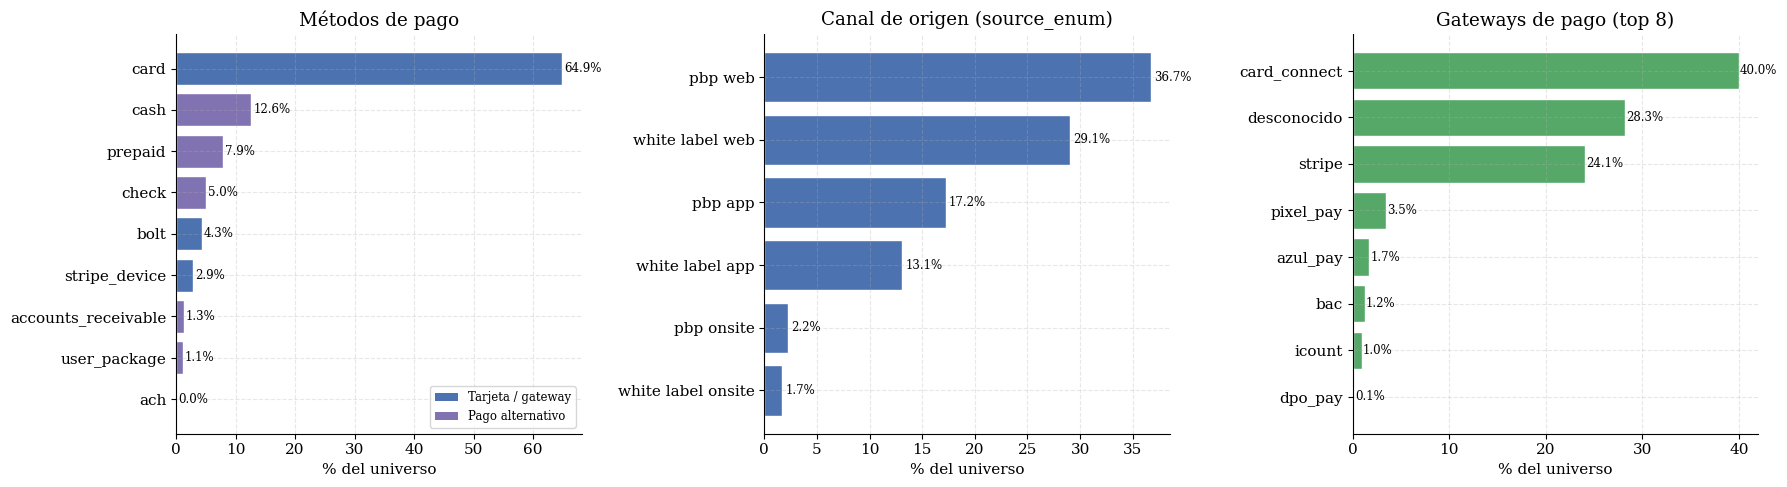

Figura y tablas guardadas.


In [6]:
# ── Figura: métodos de pago (card vs alt) y canales ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Métodos de pago — coloreados por tipo
meth_pct = (method_counts / total_rows * 100).sort_values(ascending=True)
meth_colors = [C_ALT if m in ALT_METHODS else C_NORMAL for m in meth_pct.index]
axes[0].barh(meth_pct.index, meth_pct.values, color=meth_colors, edgecolor='white')
for i, (val, m) in enumerate(zip(meth_pct.values, meth_pct.index)):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[0].set_xlabel('% del universo')
axes[0].set_title('Métodos de pago')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=C_NORMAL, label='Tarjeta / gateway'),
                         Patch(facecolor=C_ALT,    label='Pago alternativo')], fontsize=8.5)

# 2. Canales (source_enum)
src_pct = (source_counts / total_rows * 100).sort_values(ascending=True)
src_labels = [l.replace('_', ' ') for l in src_pct.index]
axes[1].barh(src_labels, src_pct.values, color=C_NORMAL, edgecolor='white')
for i, val in enumerate(src_pct.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlabel('% del universo')
axes[1].set_title('Canal de origen (source_enum)')

# 3. Gateways (top 8)
gw_top = gateway_counts.nlargest(8)
gw_pct = (gw_top / total_rows * 100).sort_values(ascending=True)
axes[2].barh(gw_pct.index, gw_pct.values, color=C_NEUTRAL, edgecolor='white')
for i, val in enumerate(gw_pct.values):
    axes[2].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[2].set_xlabel('% del universo')
axes[2].set_title('Gateways de pago (top 8)')

plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_payment_methods.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# Tablas LaTeX
def _dist_tex(counts, total, caption, label):
    df = pd.DataFrame({'Categoría': counts.index, 'N': counts.values,
                       '\\%': (counts.values/total*100).round(2)})
    df['N'] = df['N'].apply(lambda x: f'{int(x):,}')
    df['\\%'] = df['\\%'].apply(lambda x: f'{x:.2f}\\%')
    return df.to_latex(index=False, escape=False, caption=caption, label=label, column_format='lrr')

(TAB/'cap2_channel_distribution.tex').write_text(_dist_tex(source_counts, total_rows, 'Distribución por canal de origen', 'tab:channels'))
(TAB/'cap2_gateway_distribution.tex').write_text(_dist_tex(gateway_counts.nlargest(10), total_rows, 'Distribución por gateway de pago (top 10)', 'tab:gateways'))
(TAB/'cap2_payment_method_distribution.tex').write_text(_dist_tex(method_counts, total_rows, 'Distribución por método de pago', 'tab:payment-methods'))
print('Figura y tablas guardadas.')

## 2.4 Distribución de Montos
Sección: **Capítulo 2 — Variables del dataset (reservation_paid_out)**

> **Nota:** El 8.9% de transacciones tienen monto $0 en train. De estas, el 87%
> corresponde a pagos alternativos (user_package, cash, prepaid), lo que explica la discrepancia
> con cifras anteriores que incluían `payment_method='free'`.

In [7]:
df_train = dm.load_split('train')
df_train['amount'] = df_train['amount'].astype(float)
df_train['is_alt'] = df_train['payment_method'].isin(ALT_METHODS)

amt_all    = df_train['amount']
amt_card   = df_train.loc[~df_train['is_alt'], 'amount']
amt_alt    = df_train.loc[ df_train['is_alt'], 'amount']
amt_nonzero= amt_all[amt_all > 0]

def _desc(s, name):
    return {'grupo': name, 'n': int(len(s)), 'n_zero': int((s==0).sum()),
            'pct_zero': float((s==0).mean()*100),
            'mean': float(s.mean()), 'median': float(s.median()),
            'p95': float(s.quantile(.95)), 'p99': float(s.quantile(.99)),
            'max': float(s.max()), 'std': float(s.std())}

amount_stats = {
    'global':  _desc(amt_all,    'Global'),
    'card':    _desc(amt_card,   'Tarjeta/gateway'),
    'alt':     _desc(amt_alt,    'Pago alternativo'),
    'nonzero': _desc(amt_nonzero,'Global (monto>0)'),
}

for k, v in amount_stats.items():
    print(f"  {v['grupo']:25s}: mean=${v['mean']:.2f}  median=${v['median']:.2f}  P95=${v['p95']:.2f}  max=${v['max']:,.0f}  zero={v['pct_zero']:.1f}%")

2026-03-17 21:50:59 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


  Global                   : mean=$498.70  median=$28.50  P95=$526.30  max=$115,116,001  zero=8.9%
  Tarjeta/gateway          : mean=$131.74  median=$30.00  P95=$410.00  max=$1,699,000  zero=1.0%
  Pago alternativo         : mean=$1481.03  median=$23.00  P95=$1800.00  max=$115,116,001  zero=30.2%
  Global (monto>0)         : mean=$547.61  median=$31.50  P95=$600.00  max=$115,116,001  zero=0.0%


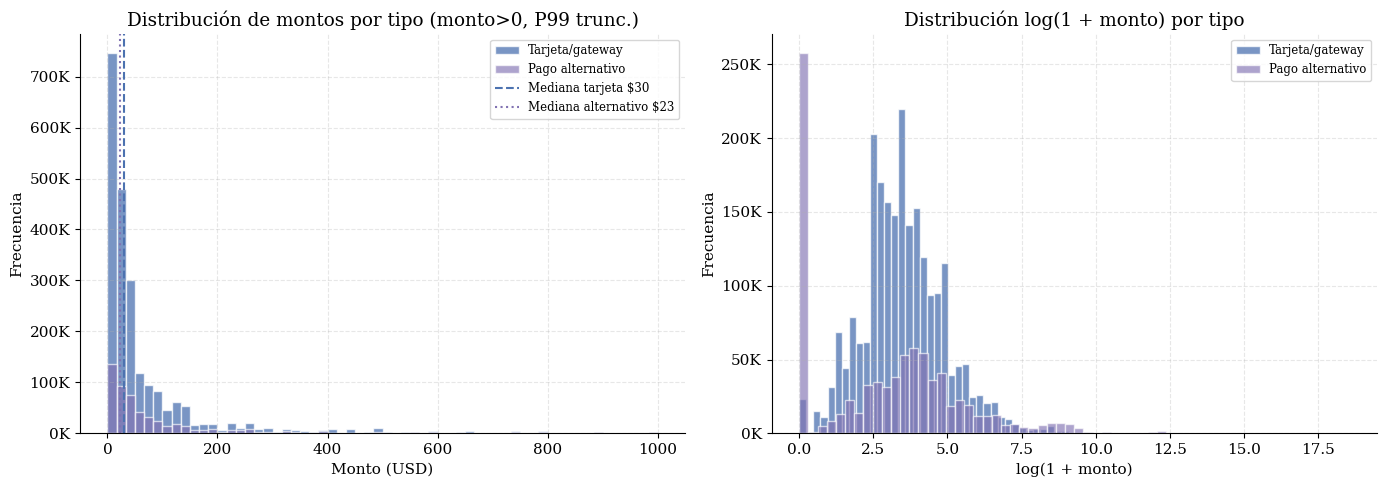

Figura y tabla guardadas.


In [8]:
# ── Figura: histogramas de monto ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_card = float(amt_card.quantile(.99))
amt_card_trunc = amt_card[(amt_card > 0) & (amt_card <= min(p99_card, 1000))]
amt_alt_trunc  = amt_alt[(amt_alt > 0) & (amt_alt <= min(p99_card, 1000))]

# Histograma por tipo de pago (truncado)
axes[0].hist(amt_card_trunc, bins=60, color=C_NORMAL, alpha=0.75, label='Tarjeta/gateway', edgecolor='white')
axes[0].hist(amt_alt_trunc,  bins=60, color=C_ALT,    alpha=0.65, label='Pago alternativo', edgecolor='white')
axes[0].axvline(float(amt_card.median()), color=C_NORMAL,  linestyle='--', linewidth=1.5, label=f'Mediana tarjeta ${amt_card.median():.0f}')
axes[0].axvline(float(amt_alt.median()),  color=C_ALT,     linestyle=':',  linewidth=1.5, label=f'Mediana alternativo ${amt_alt.median():.0f}')
axes[0].set_xlabel('Monto (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de montos por tipo (monto>0, P99 trunc.)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend(fontsize=8.5)

# log(1+amount)
log_card = np.log1p(amt_card[amt_card >= 0])
log_alt  = np.log1p(amt_alt[amt_alt >= 0])
axes[1].hist(log_card, bins=60, color=C_NORMAL, alpha=0.75, label='Tarjeta/gateway', edgecolor='white')
axes[1].hist(log_alt,  bins=60, color=C_ALT,    alpha=0.65, label='Pago alternativo', edgecolor='white')
axes[1].set_xlabel('log(1 + monto)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución log(1 + monto) por tipo')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].legend(fontsize=8.5)

plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_amount_distribution.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# Tabla descriptiva LaTeX
rows = []
for k in ['global','card','alt','nonzero']:
    v = amount_stats[k]
    rows.append([v['grupo'], f"{v['n']:,}", f"{v['pct_zero']:.1f}\\%",
                 f"\\${v['mean']:,.2f}", f"\\${v['median']:,.2f}",
                 f"\\${v['p95']:,.2f}", f"\\${v['p99']:,.2f}"])
desc_df = pd.DataFrame(rows, columns=['Grupo','N','\\% Monto=0','Media','Mediana','P95','P99'])
tex_desc = desc_df.to_latex(index=False, escape=False,
    caption='Estadísticas descriptivas del monto transaccional (split train)',
    label='tab:amount-descriptive', column_format='lrrrrrrr')
(TAB/'cap2_amount_descriptive.tex').write_text(tex_desc)
print('Figura y tabla guardadas.')

## 2.5 Patrones Temporales
Sección: **Capítulo 2 — Análisis temporal de transacciones**

2026-03-17 21:51:03 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


2026-03-17 21:51:05 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded val: 1,130,118 rows


2026-03-17 21:51:07 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded test: 2,517,491 rows


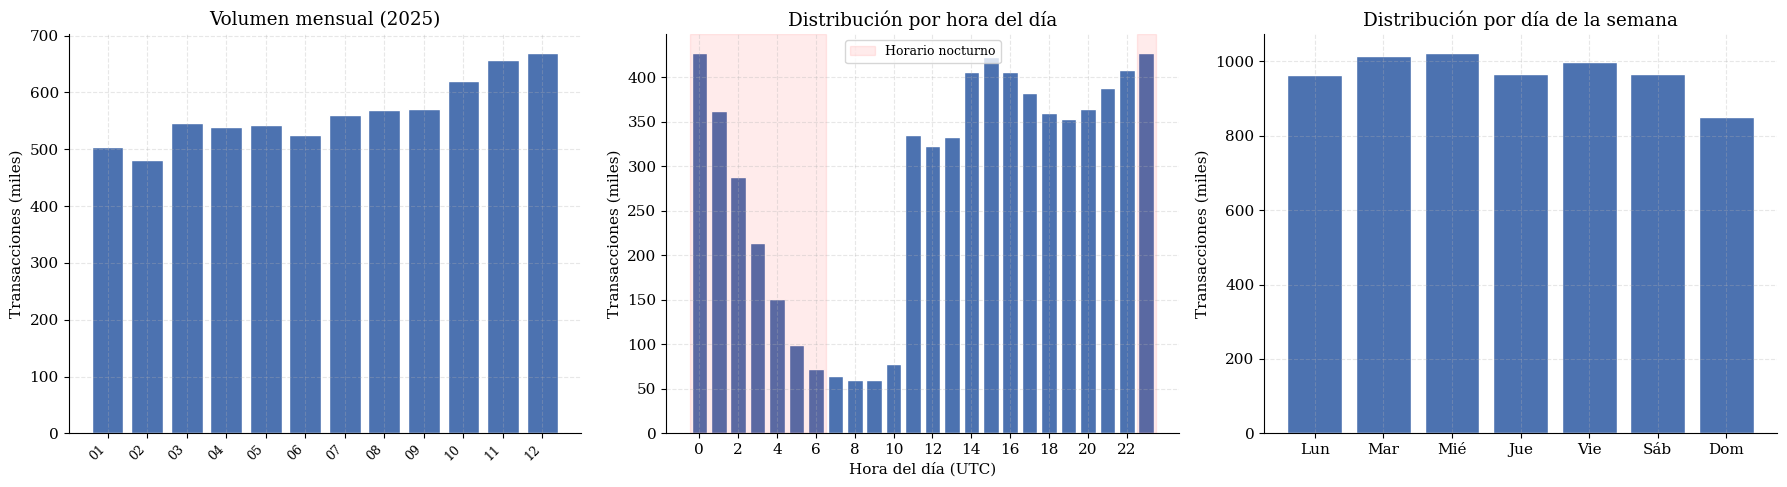

Figura y tabla guardadas.


In [9]:
hourly  = pd.Series(0, index=range(24), dtype=int)
daily   = pd.Series(0, index=range(7),  dtype=int)
monthly = pd.Series(dtype=int)

for name in ['train', 'val', 'test']:
    df = dm.load_split(name)[['created_at']]
    hourly  = hourly.add(df['created_at'].dt.hour.value_counts(),       fill_value=0).astype(int)
    daily   = daily.add(df['created_at'].dt.dayofweek.value_counts(),   fill_value=0).astype(int)
    ym = df['created_at'].dt.to_period('M').astype(str)
    monthly = monthly.add(ym.value_counts(), fill_value=0).astype(int)
    del df; gc.collect()

monthly = monthly.sort_index()

# ── Figura: patrones temporales ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mensual
x = range(len(monthly))
axes[0].bar(x, monthly.values / 1e3, color=C_NORMAL, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m[5:] for m in monthly.index], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Transacciones (miles)')
axes[0].set_title('Volumen mensual (2025)')

# Horario
axes[1].bar(hourly.index, hourly.values / 1e3, color=C_NORMAL, edgecolor='white')
axes[1].axvspan(-0.5, 6.5,  alpha=0.08, color='red')
axes[1].axvspan(22.5, 23.5, alpha=0.08, color='red', label='Horario nocturno')
axes[1].set_xlabel('Hora del día (UTC)')
axes[1].set_ylabel('Transacciones (miles)')
axes[1].set_title('Distribución por hora del día')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=9)

# Día de semana
day_labels = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
axes[2].bar(day_labels, daily.sort_index().values / 1e3, color=C_NORMAL, edgecolor='white')
axes[2].set_ylabel('Transacciones (miles)')
axes[2].set_title('Distribución por día de la semana')

plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_temporal_patterns.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# Tabla mensual LaTeX
monthly_df = pd.DataFrame({'Mes': monthly.index, 'N': monthly.values,
                            '\\%': (monthly.values/total_rows*100).round(2)})
monthly_df['N'] = monthly_df['N'].apply(lambda x: f'{x:,}')
monthly_df['\\%'] = monthly_df['\\%'].apply(lambda x: f'{x:.2f}\\%')
tex_m = monthly_df.to_latex(index=False, escape=False,
    caption='Volumen transaccional mensual (Ene--Dic 2025)',
    label='tab:monthly-volume', column_format='lrr')
(TAB/'cap2_monthly_volume.tex').write_text(tex_m)
print('Figura y tabla guardadas.')

## 2.6 Estabilidad Temporal del Proxy
Sección: **Capítulo 2 — Consistencia de la variable criterio**

2026-03-17 21:51:11 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


2026-03-17 21:51:13 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded val: 1,130,118 rows


2026-03-17 21:51:15 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded test: 2,517,491 rows


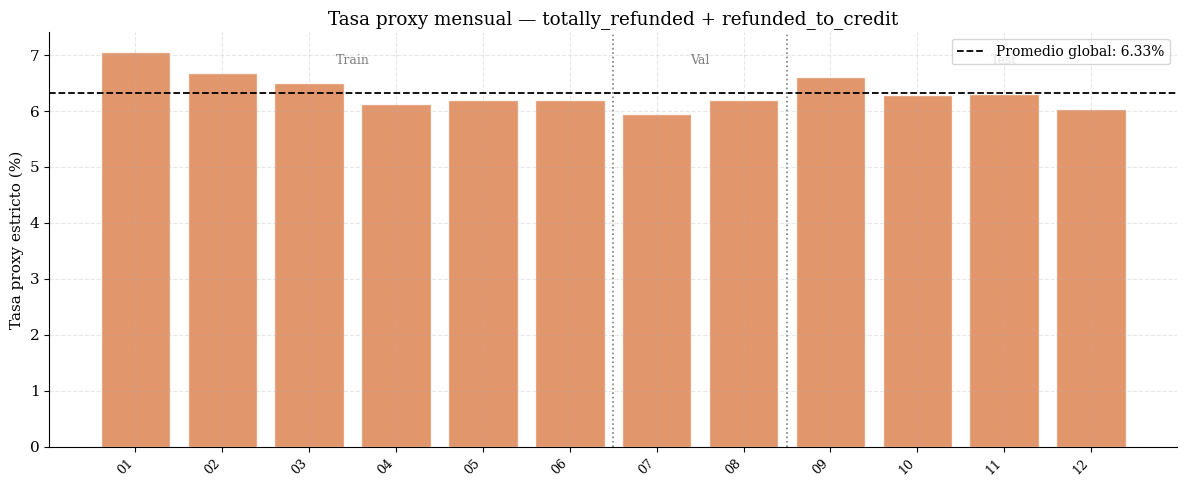

    mes      n  proxy_n     rate
2025-01 504219    35564 7.053284
2025-02 480558    32130 6.685978
2025-03 545553    35506 6.508259
2025-04 538630    33029 6.132039
2025-05 543501    33664 6.193917
2025-06 524624    32465 6.188241
2025-07 560240    33327 5.948701
2025-08 569878    35297 6.193782
2025-09 570982    37680 6.599157
2025-10 620146    38963 6.282875
2025-11 656604    41407 6.306236
2025-12 669759    40466 6.041875


In [10]:
proxy_monthly = {}

for name in ['train', 'val', 'test']:
    df = dm.load_split(name)[['created_at','status']]
    df['ym']       = df['created_at'].dt.to_period('M').astype(str)
    df['is_proxy'] = df['status'].isin(PROXY_STRICT).astype(int)
    for ym, grp in df.groupby('ym'):
        if ym not in proxy_monthly:
            proxy_monthly[ym] = {'n': 0, 'proxy_n': 0}
        proxy_monthly[ym]['n']       += len(grp)
        proxy_monthly[ym]['proxy_n'] += int(grp['is_proxy'].sum())
    del df; gc.collect()

proxy_df = pd.DataFrame([
    {'mes': k, 'n': v['n'], 'proxy_n': v['proxy_n'], 'rate': v['proxy_n']/v['n']*100}
    for k, v in sorted(proxy_monthly.items())
])

# ── Figura: tasa proxy mensual ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(proxy_df))
bars = ax.bar(x, proxy_df['rate'], color=C_ANOMALY, edgecolor='white', alpha=0.85)

avg_rate = total_ps / total_rows * 100
ax.axhline(avg_rate, color='black', linestyle='--', linewidth=1.3, label=f'Promedio global: {avg_rate:.2f}%')

# Línea divisoria entre splits
train_months = [k for k in sorted(proxy_monthly) if k < '2025-07']
val_months   = [k for k in sorted(proxy_monthly) if '2025-07' <= k < '2025-09']
if train_months and val_months:
    ax.axvline(len(train_months) - 0.5, color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(len(train_months) + len(val_months) - 0.5, color='gray', linestyle=':', linewidth=1.2)
    mid_train = (len(train_months) - 1) / 2
    ax.text(mid_train, proxy_df['rate'].max() * 0.97, 'Train', ha='center', fontsize=9, color='gray')
    mid_val = len(train_months) + (len(val_months) - 1) / 2
    ax.text(mid_val, proxy_df['rate'].max() * 0.97, 'Val', ha='center', fontsize=9, color='gray')
    mid_test = len(train_months) + len(val_months) + 2
    ax.text(mid_test, proxy_df['rate'].max() * 0.97, 'Test', ha='center', fontsize=9, color='gray')

ax.set_xticks(x)
ax.set_xticklabels([m[5:] for m in proxy_df['mes']], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Tasa proxy estricto (%)')
ax.set_title('Tasa proxy mensual — totally_refunded + refunded_to_credit')
ax.legend(fontsize=10)
plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_proxy_rate_monthly.{fmt}', dpi=150, bbox_inches='tight')
plt.show()
print(proxy_df[['mes','n','proxy_n','rate']].to_string(index=False))

## 2.7 Perfil proxy+ vs. proxy−
Sección: **Capítulo 2 — Evidencia de diferencias observables entre grupos**

In [11]:
df_p = dm.load_split('train')[['status','amount','created_at','source_enum','gateway','payment_method']]
df_p['amount']   = df_p['amount'].astype(float)
df_p['is_proxy'] = df_p['status'].isin(PROXY_STRICT)
df_p['is_alt']   = df_p['payment_method'].isin(ALT_METHODS)
df_p['hour']     = df_p['created_at'].dt.hour

proxy_pos = df_p[df_p['is_proxy']]
proxy_neg = df_p[~df_p['is_proxy']]

print(f'proxy+ (train): {len(proxy_pos):,} ({len(proxy_pos)/len(df_p)*100:.2f}%)')
print(f'proxy- (train): {len(proxy_neg):,} ({len(proxy_neg)/len(df_p)*100:.2f}%)')
print()
for grp_name, grp in [('proxy+', proxy_pos), ('proxy-', proxy_neg)]:
    a = grp['amount']
    print(f'  {grp_name}: mean=${a.mean():.2f}  median=${a.median():.2f}  P95=${a.quantile(.95):.2f}  std=${a.std():.2f}')
    print(f'    alt_payment: {grp["is_alt"].mean()*100:.1f}% | top_canal: {grp["source_enum"].value_counts().index[0]}')

2026-03-17 21:51:19 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


proxy+ (train): 202,358 (6.45%)
proxy- (train): 2,934,727 (93.55%)

  proxy+: mean=$219.02  median=$35.60  P95=$537.50  std=$1991.90
    alt_payment: 22.7% | top_canal: pbp_app
  proxy-: mean=$517.99  median=$28.02  P95=$525.27  std=$125998.09
    alt_payment: 27.5% | top_canal: pbp_web


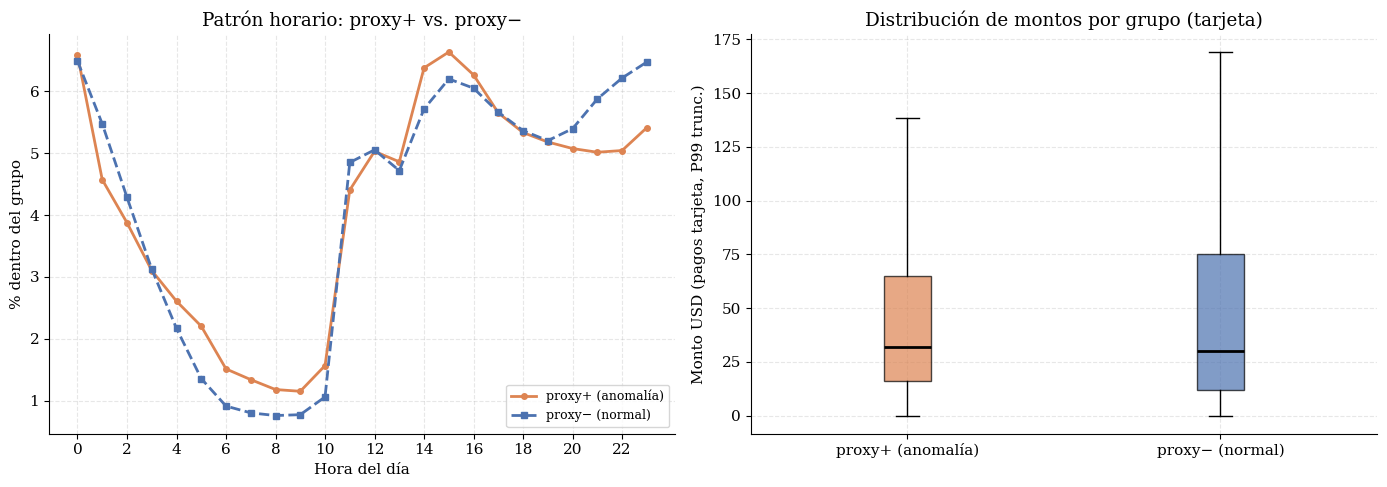

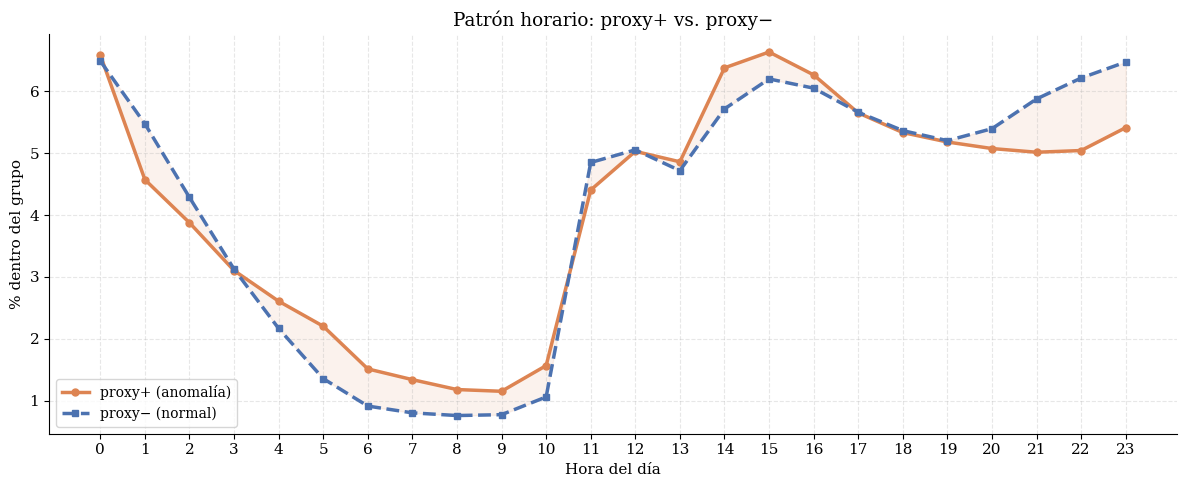

Figura y tabla guardadas.


In [12]:
# ── Figura: proxy+ vs proxy− ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución horaria
h_pos = proxy_pos['hour'].value_counts().sort_index() / len(proxy_pos) * 100
h_neg = proxy_neg['hour'].value_counts().sort_index() / len(proxy_neg) * 100
axes[0].plot(h_pos.index, h_pos.values, color=C_ANOMALY, linewidth=2, marker='o', markersize=4, label='proxy+ (anomalía)')
axes[0].plot(h_neg.index, h_neg.values, color=C_NORMAL,  linewidth=2, linestyle='--', marker='s', markersize=4, label='proxy− (normal)')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('% dentro del grupo')
axes[0].set_title('Patrón horario: proxy+ vs. proxy−')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(0, 24, 2))

# Box plot de montos por grupo (tarjeta, monto>0, P99 trunc)
p99 = float(df_p[~df_p['is_alt']]['amount'].quantile(.99))
card_proxy_pos = proxy_pos[(~proxy_pos['is_alt']) & (proxy_pos['amount'] > 0) & (proxy_pos['amount'] <= p99)]['amount']
card_proxy_neg = proxy_neg[(~proxy_neg['is_alt']) & (proxy_neg['amount'] > 0) & (proxy_neg['amount'] <= p99)]['amount']
bp = axes[1].boxplot([card_proxy_pos.sample(min(50000, len(card_proxy_pos))),
                      card_proxy_neg.sample(min(50000, len(card_proxy_neg)))],
                     labels=['proxy+ (anomalía)', 'proxy− (normal)'],
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(C_ANOMALY)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(C_NORMAL)
bp['boxes'][1].set_alpha(0.7)
axes[1].set_ylabel('Monto USD (pagos tarjeta, P99 trunc.)')
axes[1].set_title('Distribución de montos por grupo (tarjeta)')

plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_proxy_amounts.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# Figura horaria separada
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(h_pos.index, h_pos.values, color=C_ANOMALY, linewidth=2.5, marker='o', markersize=5, label='proxy+ (anomalía)')
ax2.plot(h_neg.index, h_neg.values, color=C_NORMAL,  linewidth=2.5, linestyle='--', marker='s', markersize=5, label='proxy− (normal)')
ax2.fill_between(h_pos.index, h_pos.values, h_neg.values, alpha=0.1, color=C_ANOMALY)
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('% dentro del grupo')
ax2.set_title('Patrón horario: proxy+ vs. proxy−')
ax2.legend(fontsize=10)
ax2.set_xticks(range(24))
plt.tight_layout()
for fmt in ['pdf', 'png']:
    plt.savefig(FIG / f'cap2_hourly_proxy.{fmt}', dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa LaTeX
def _grp_profile(grp, name):
    a = grp['amount']
    return {'Grupo': name, 'N': f"{len(grp):,}",
            '\\% total': f"{len(grp)/len(df_p)*100:.2f}\\%",
            'Media (USD)': f"\\${a.mean():.2f}", 'Mediana (USD)': f"\\${a.median():.2f}",
            'P95 (USD)': f"\\${a.quantile(.95):.2f}",
            '\\% pago alt.': f"{grp['is_alt'].mean()*100:.1f}\\%"}

profile_df = pd.DataFrame([_grp_profile(proxy_pos,'proxy+ (anomalía)'), _grp_profile(proxy_neg,'proxy− (normal)')])
tex_profile = profile_df.to_latex(index=False, escape=False,
    caption='Perfil comparativo proxy+ vs. proxy− (split train)',
    label='tab:proxy-profiles', column_format='lrrrrrr')
(TAB/'cap2_proxy_profiles.tex').write_text(tex_profile)
del df_p, proxy_pos, proxy_neg; gc.collect()
print('Figura y tabla guardadas.')

## 2.8 Outliers y Patrones Extremos
Sección: **Capítulo 2 — Anomalías observadas en el dataset**

In [13]:
df_out = dm.load_split('train')[['id','user_id','facility_id','status','amount','created_at','payment_method']]
df_out['amount'] = df_out['amount'].astype(float)

# 1. Montos > $1M
extreme = df_out[df_out['amount'] > 1_000_000].sort_values('amount', ascending=False)
print(f'Montos > $1M: {len(extreme)} transacciones')
if len(extreme):
    print(extreme[['id','status','amount','payment_method','created_at']].head(10).to_string(index=False))

print()
# 2. Usuarios con ≥5 txns y 100% tasa de reembolso
user_st = df_out.groupby('user_id').agg(
    n=('id','count'),
    proxy_n=('status', lambda x: x.isin(PROXY_STRICT).sum())
).query('n >= 5')
user_st['rate'] = user_st['proxy_n'] / user_st['n']
full_refund = user_st[user_st['rate'] == 1.0]
print(f'Usuarios 100% reembolso (≥5 txns): {len(full_refund):,} | txns acumuladas: {full_refund["n"].sum():,}')

# 3. Velocidad máxima diaria
df_out['date'] = df_out['created_at'].dt.date
daily_vel = df_out.groupby(['user_id','date']).size().reset_index(name='txns')
max_day   = int(daily_vel['txns'].max())
high_vel  = daily_vel[daily_vel['txns'] >= 50]
print(f'Máximo txns/día: {max_day} | Usuarios-día con ≥50 txns: {len(high_vel):,}')

# 4. Facilities con proxy_rate > 20% (≥100 txns)
fac_st = df_out.groupby('facility_id').agg(
    n=('id','count'),
    proxy_n=('status', lambda x: x.isin(PROXY_STRICT).sum())
).query('n >= 100')
fac_st['rate'] = fac_st['proxy_n'] / fac_st['n']
high_fac = fac_st[fac_st['rate'] > 0.20].sort_values('rate', ascending=False)
print(f'Facilities proxy_rate>20% (≥100 txns): {len(high_fac)} | max: {high_fac["rate"].max()*100:.1f}%')

outlier_stats = {
    'amount_zero_train_n':      int((df_out['amount']==0).sum()),
    'amount_zero_train_pct':    float((df_out['amount']==0).mean()*100),
    'amount_over_1M':           int(len(extreme)),
    'amount_over_1M_max_usd':   float(extreme['amount'].max()) if len(extreme) else 0,
    'users_100pct_refund':      int(len(full_refund)),
    'max_txns_per_day':         max_day,
    'userdays_50plus_txns':     int(len(high_vel)),
    'facilities_proxy_gt20pct': int(len(high_fac)),
}
del df_out; gc.collect()

2026-03-17 21:51:23 | INFO     | fraud_detector.data.loader:load_split:219 - Loaded train: 3,137,085 rows


Montos > $1M: 11 transacciones
      id   status      amount payment_method          created_at
26381789          115116001.0        prepaid 2025-06-22 15:46:28
26380364          115001000.0           cash 2025-06-22 15:13:31
25216681           99999999.0           cash 2025-05-28 22:33:26
25216722           99999999.0           cash 2025-05-28 22:34:18
26149818 captured   1699000.0           card 2025-06-17 15:47:21
26164902 captured   1699000.0           card 2025-06-17 21:07:40
26537198 captured   1699000.0           card 2025-06-25 18:55:06
24827770            1559500.0           cash 2025-05-20 15:34:20
20957838            1137080.0           cash 2025-02-24 14:40:09
21992629            1100940.0           cash 2025-03-19 14:18:31



Usuarios 100% reembolso (≥5 txns): 25 | txns acumuladas: 165


Máximo txns/día: 636 | Usuarios-día con ≥50 txns: 625
Facilities proxy_rate>20% (≥100 txns): 17 | max: 69.9%


30

## 2.9 Estado Actual del Sistema de Detección
Sección: **Capítulo 2 — Vacío del sistema (justificación del OE1)**

TechSport Inc. **no cuenta** con un sistema de detección de anomalías transaccionales:

- No existe scoring de riesgo por transacción.
- El proceso de reembolso es **100% reactivo y manual** — el cliente disputa → operador procesa reembolso.
- No hay priorización ni clasificación automática de alertas.
- La columna `is_fraud` **no existe** en el esquema de la base de datos (documentado en la tesis).
- Esta ausencia justifica el enfoque no supervisado con validación por proxy (OE1).

In [14]:
# ── Exportar cap2_summary.json ────────────────────────────────────────────────
cap2_summary = {
    'generated_at':  pd.Timestamp.now().isoformat(),
    'data_source':   'data/processed/*_raw.parquet (snapshot Fase 1, 2026-03-17)',
    'universe': {
        'total_rows':         total_rows,
        'proxy_strict_n':     total_ps,
        'proxy_strict_pct':   round(total_ps/total_rows*100, 4),
        'proxy_wide_n':       total_pw,
        'proxy_wide_pct':     round(total_pw/total_rows*100, 4),
        'alt_payment_n':      total_alt,
        'alt_payment_pct':    round(total_alt/total_rows*100, 4),
        'card_payment_n':     total_rows - total_alt,
        'card_payment_pct':   round((total_rows-total_alt)/total_rows*100, 4),
    },
    'splits':                split_stats,
    'status_distribution':   status_df[['label','n','pct','amount_mean']].to_dict(orient='records'),
    'amount_stats':          amount_stats,
    'channel_distribution':  source_counts.to_dict(),
    'gateway_distribution':  gateway_counts.head(10).to_dict(),
    'payment_method_distribution': method_counts.to_dict(),
    'currency_distribution': currency_counts.to_dict(),
    'proxy_rate_by_month':   proxy_df.set_index('mes')[['n','proxy_n','rate']].to_dict(),
    'outliers':              outlier_stats,
    'detection_gap': {
        'has_fraud_labels':              False,
        'has_anomaly_detection_system':  False,
        'refund_process':                'manual_reactive',
        'justifies_oe1':                 True,
    },
    'notes': {
        'sin_estado': 'status=="" corresponde a pagos con métodos alternativos (cash, prepaid, check, ACH, user_package). No pasan por gateway bancario, no reciben status de captura.',
        'amount_zero': '8.93% de transacciones en train tienen monto=0; el 87% son pagos alternativos (user_package, cash, prepaid).',
        'proxy_rate_per_split': 'train=6.45%, val=6.07%, test=6.30% — estabilidad temporal confirmada.',
    }
}

(MET/'cap2_summary.json').write_text(json.dumps(cap2_summary, indent=2, default=str))
print('cap2_summary.json guardado.')

print('\n' + '='*62)
print('ARTEFACTOS GENERADOS — Capítulo 2')
print('='*62)
tablas  = sorted(TAB.glob('cap2_*.tex'))
figuras = sorted(FIG.glob('cap2_*.*'))
print(f'  Tablas LaTeX ({len(tablas)}):'); [print(f'    {t.name}') for t in tablas]
print(f'  Figuras ({len(figuras)}):');     [print(f'    {f.name}') for f in figuras]
print(f'  Métricas: output/metrics/cap2_summary.json')
print()
print(f'  N total:       {total_rows:>12,}')
print(f'  proxy_strict:  {total_ps:>12,}  ({total_ps/total_rows*100:.2f}%)')
print(f'  proxy_wide:    {total_pw:>12,}  ({total_pw/total_rows*100:.2f}%)')
print(f'  alt_payment:   {total_alt:>12,}  ({total_alt/total_rows*100:.2f}%)')

cap2_summary.json guardado.

ARTEFACTOS GENERADOS — Capítulo 2
  Tablas LaTeX (8):
    cap2_amount_by_status.tex
    cap2_amount_descriptive.tex
    cap2_channel_distribution.tex
    cap2_gateway_distribution.tex
    cap2_monthly_volume.tex
    cap2_payment_method_distribution.tex
    cap2_proxy_profiles.tex
    cap2_status_distribution.tex
  Figuras (14):
    cap2_amount_distribution.pdf
    cap2_amount_distribution.png
    cap2_hourly_proxy.pdf
    cap2_hourly_proxy.png
    cap2_payment_methods.pdf
    cap2_payment_methods.png
    cap2_proxy_amounts.pdf
    cap2_proxy_amounts.png
    cap2_proxy_rate_monthly.pdf
    cap2_proxy_rate_monthly.png
    cap2_status_distribution.pdf
    cap2_status_distribution.png
    cap2_temporal_patterns.pdf
    cap2_temporal_patterns.png
  Métricas: output/metrics/cap2_summary.json

  N total:          6,784,694
  proxy_strict:       429,498  (6.33%)
  proxy_wide:         512,676  (7.56%)
  alt_payment:      1,893,554  (27.91%)
